In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../")

from src.core.config import load_config
from src.sim.sim_loop import run_midblock_simulation
from src.metrics.density_flow import flow_density_from_log

os.makedirs("figures", exist_ok=True)

config = load_config("../configs/intersection_default.yaml")
rng = np.random.default_rng(config['simulation']['random_seed'])
duration_s = 3600
window_s = 300 # 5 minute windows

densities = []
flows = []

rates = [200, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]
for rate in rates:
    print(f"Running simulation at {rate} veh/hr...")
    df = run_midblock_simulation(config, rate, duration_s, rng)
    
    fd_df = flow_density_from_log(df, 
                                  road_length_cells=int(config['midblock_test']['road_length_m'] / config['grid']['cell_length_m']), 
                                  cell_length_m=config['grid']['cell_length_m'], 
                                  window_s=window_s)
    
    # Exclude empty windows or burn-in (first window)
    if len(fd_df) > 1:
        densities.extend(fd_df['density_veh_per_km'].iloc[1:].tolist())
        flows.extend(fd_df['flow_veh_per_hr'].iloc[1:].tolist())


Running simulation at 200 veh/hr...
Running simulation at 500 veh/hr...


Running simulation at 1000 veh/hr...


Running simulation at 1500 veh/hr...


Running simulation at 2000 veh/hr...


Running simulation at 2500 veh/hr...


Running simulation at 3000 veh/hr...


Running simulation at 3500 veh/hr...


Running simulation at 4000 veh/hr...


Running simulation at 4500 veh/hr...


Running simulation at 5000 veh/hr...


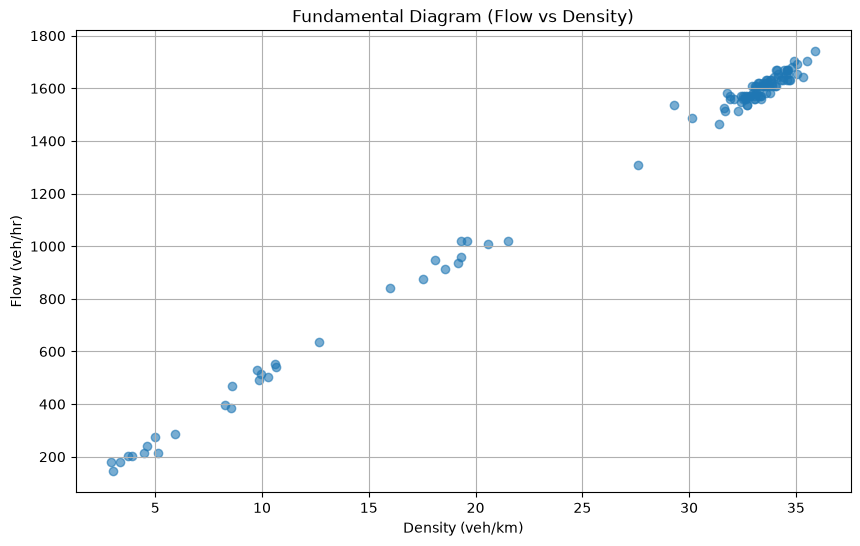

In [2]:
plt.figure(figsize=(10, 6))
plt.scatter(densities, flows, alpha=0.6)
plt.title("Fundamental Diagram (Flow vs Density)")
plt.xlabel("Density (veh/km)")
plt.ylabel("Flow (veh/hr)")
plt.grid(True)
plt.savefig("figures/phase1_fundamental_diagram.png")
plt.show()